# Défi IA 2025 - CNES

La mission ARIEL de l'ESA, prévue pour un lancement en 2029, cherche à caractériser l'atmosphère de 1000 exoplanètes.  
Elle utilise une méthode d'observation indirecte des exoplanètes en restant fixé sur la lumière de son étoile hôte et en attendant de voir la période de transit, c'est à dire le moment où la planète passe devant l'étoile.  
L'objectif de ce défi IA est d'extraire depuis des observations d'ARIEL simulées la présence ou l'absence d'eau et de nuages.

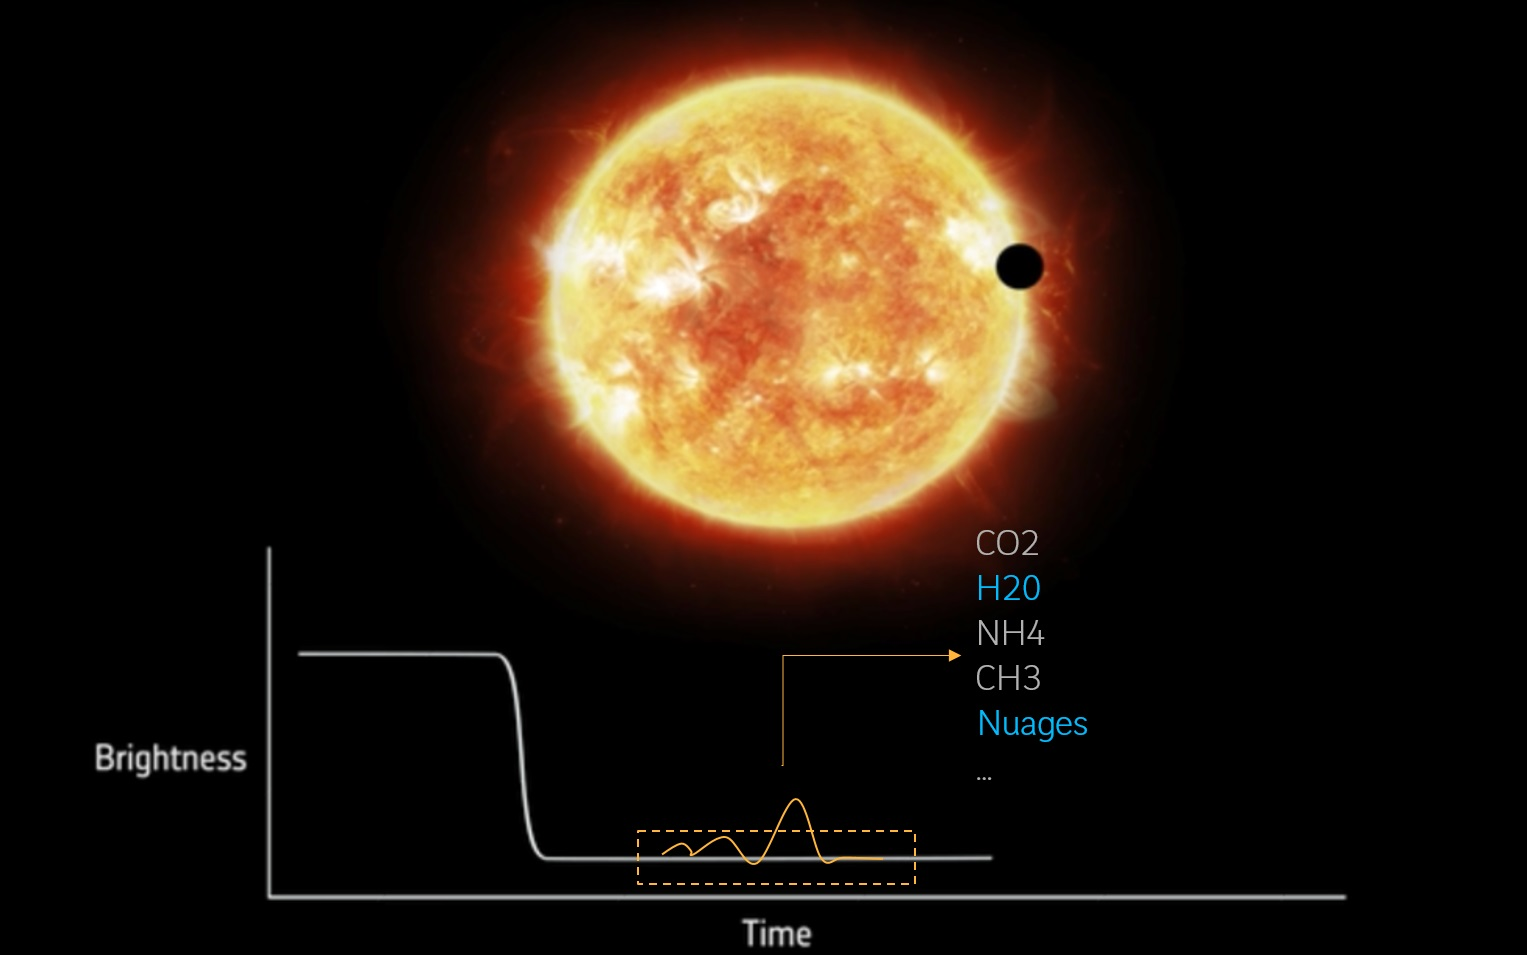

## Données d'entrée : spectre

Le transit impacte le rapport de flux au travers des longueurs d'onde observées par les instrumets d'ARIEL : FGS et AIRS. La pipeline de transformation de données d'ARIEL transforme l'observation d'un transit en un spectre exploitable, c'est le produit de niveau 3.  
Dans ce Défi IA, le spectre est la principale entrée. 

Le spectre donne pour chaque longueur d'onde la profondeur de transit. Les instruments FGS (caméra visible, gamme spectrale de 1.1 à 1.95 microns) et AIRS (spectromètre infrarouge, gamme spectrale de 1.95 à 7.8 microns) sont sujets à différents bruits pendant leurs observations. Les points du spectre sont donc partiellement incertains à un degré défini dans les spécifications de la mission.  
Les spectres du défi IA proviennent d'un simulateur appelé Taurex, permettant une fidèle représentativité des instruments FGS et ARIEL.
Dans le jeu de données du défi IA, le spectre est échantilloné sur 52 points de données, avec pour chaque point l'information d'incertitude et la moyenne dans l'incertitude.

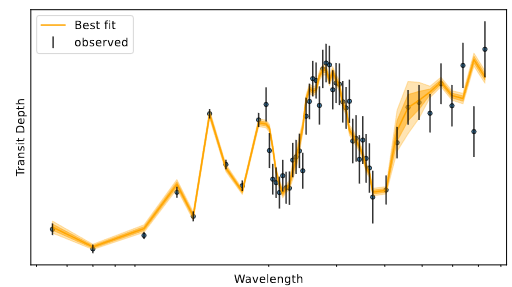

## Données d'entrée : les informations auxiliaires
En plus du spectre, des informations du système planètaire sont disponibles pour chaque opération. Elles correspondent aux paramètres de l’étoile, à la masse de la planète et au demi grand-axe.

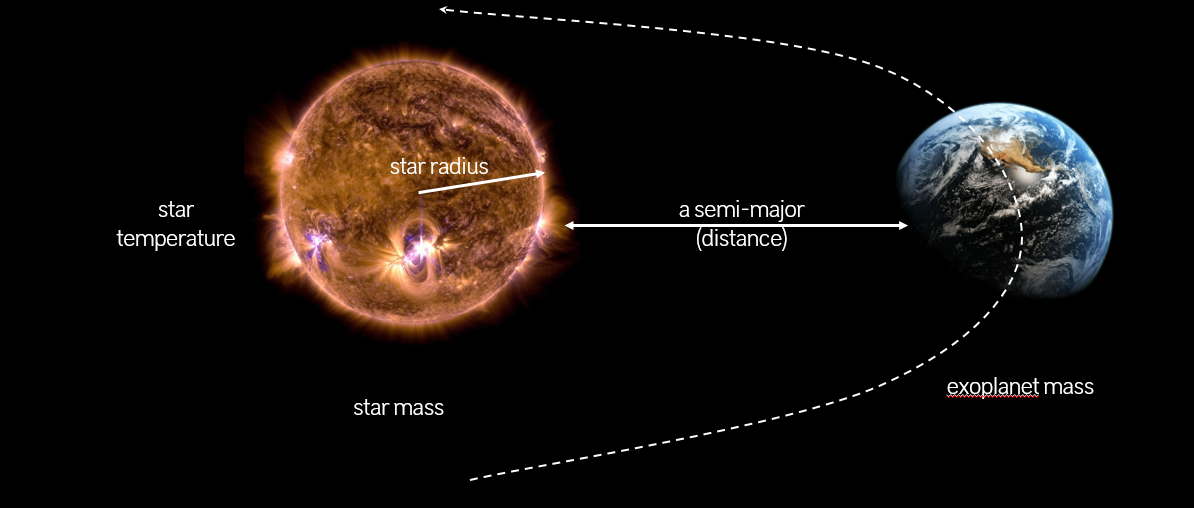

## Imports et familiarisation avec Kaggle

In [1]:
import pandas as pd
import os
import h5py
import numpy as np
import pickle
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/defi-ia-2025-cnes/auxiliary_test.csv
/kaggle/input/defi-ia-2025-cnes/targets.csv
/kaggle/input/defi-ia-2025-cnes/spectra.npy
/kaggle/input/defi-ia-2025-cnes/spectra_test.npy
/kaggle/input/defi-ia-2025-cnes/auxiliary.csv


In [2]:
root_dataset = '/kaggle/input/defi-ia-2025-cnes'
spectra_train = np.load(f'{root_dataset}/spectra.npy')
auxiliary_train = pd.read_csv(f'{root_dataset}/auxiliary.csv')
targets_train = pd.read_csv(f'{root_dataset}/targets.csv')

In [3]:
spectra_train

array([[[7.27555920e+00, 9.70204688e-04, 1.52272346e-06],
        [6.81373911e+00, 9.70978975e-04, 1.36892043e-06],
        [6.38123330e+00, 9.69837948e-04, 1.18543536e-06],
        ...,
        [9.50000000e-01, 9.69855896e-04, 7.79703838e-08],
        [7.00000000e-01, 9.69962298e-04, 5.27452218e-08],
        [5.50000000e-01, 9.70015256e-04, 3.51582460e-08]],

       [[7.27555920e+00, 9.28926472e-04, 1.45509458e-06],
        [6.81373911e+00, 9.28081182e-04, 1.30812241e-06],
        [6.38123330e+00, 9.28619197e-04, 1.13278649e-06],
        ...,
        [9.50000000e-01, 9.25747462e-04, 7.45074766e-08],
        [7.00000000e-01, 9.25373190e-04, 5.04026424e-08],
        [5.50000000e-01, 9.25556466e-04, 3.35967590e-08]],

       [[7.27555920e+00, 1.84794103e-03, 2.89431772e-06],
        [6.81373911e+00, 1.84739796e-03, 2.60197649e-06],
        [6.38123330e+00, 1.84257929e-03, 2.25321711e-06],
        ...,
        [9.50000000e-01, 1.84263983e-03, 1.48202264e-07],
        [7.00000000e-01, 1.84

In [4]:
auxiliary_train

,star_mass_kg,star_radius_m,star_temperature,planet_mass_kg,semi_major_axis_m
0,1.570836e+30,494402820.0,5033.0,1.262481e+26,2.277510e+10
1,1.710024e+30,591890700.0,5320.0,3.959436e+25,1.217744e+10
2,1.153272e+30,382988100.0,3985.0,8.958000e+25,1.057672e+10
3,3.777960e+29,146231820.0,2988.0,3.810136e+25,1.431672e+10
4,1.371996e+30,445658880.0,4925.0,8.360800e+25,1.795200e+10
...,...,...,...,...,...
2995,1.710024e+30,591890700.0,5320.0,3.959436e+25,1.217744e+10
2996,1.292460e+30,452622300.0,4316.0,2.305192e+25,1.171368e+10
2997,2.187240e+30,779903040.0,6169.0,1.586760e+26,4.425168e+10
2998,1.153272e+30,382988100.0,3985.0,8.958000e+25,1.057672e+10


In [5]:
targets_train

,id,eau,nuage
0,0,0,1
1,1,1,0
2,2,0,0
3,3,1,1
4,4,1,1
...,...,...,...
2995,2995,0,1
2996,2996,1,0
2997,2997,1,0
2998,2998,0,0


### Affichage d'un spectre

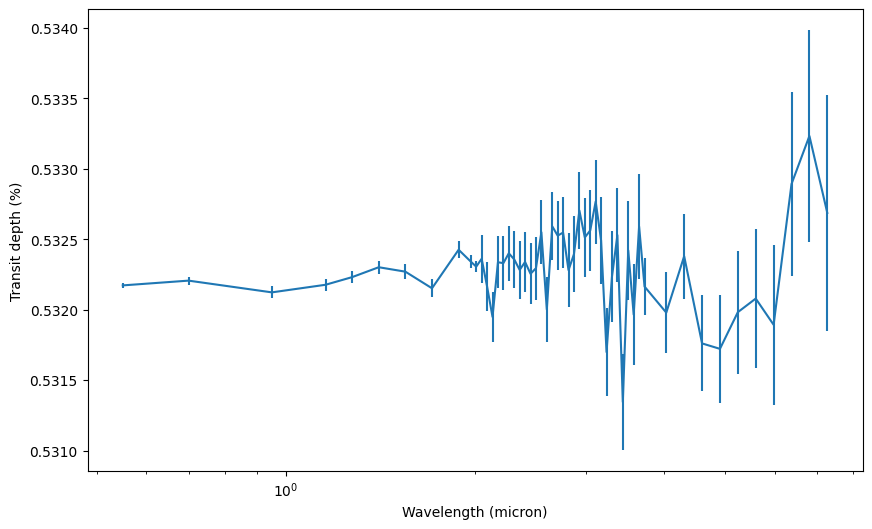

In [6]:

def visualise_spectrum(spectrum):
    ## Multipication par 100 pour passer en pourcentage 
    plt.errorbar(x=spectrum[:,0], y= spectrum[:,1]*100, yerr=spectrum[:,2]*100 )
    ## On a l'habitude de lire les spectres en échelle log
    plt.xscale('log')
    plt.xlabel('Wavelength (micron)')
    plt.ylabel('Transit depth (%)')

fig = plt.figure(figsize=(10,6))
visualise_spectrum(spectra_train[3])
plt.show()

### Affichage d'un autre spectre

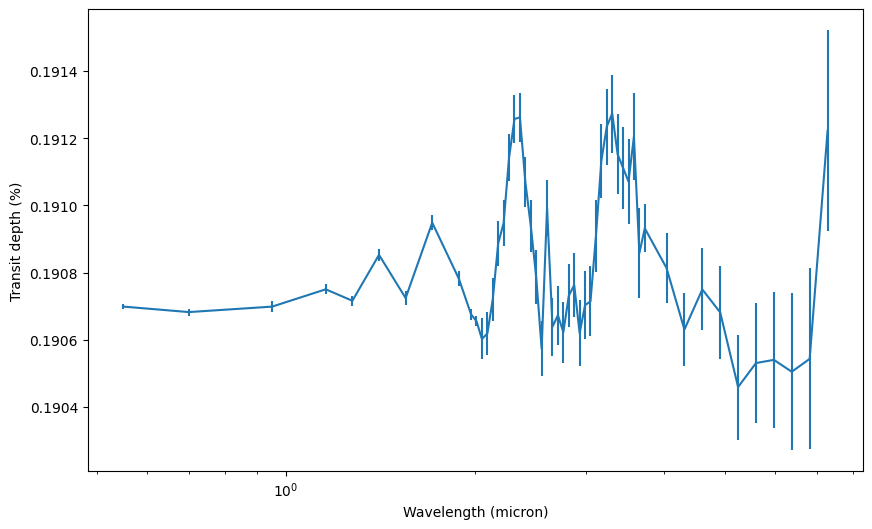

In [7]:
fig = plt.figure(figsize=(10,6))
visualise_spectrum(spectra_train[400])
plt.show()

On peut observer que la moyenne du spectre diffère sensiblement d'un spectre à un autre, c'est un effet direct de la taille du rayon. Plus une planète est large, plus son rapport de profondeur de transit sera important. On peut également voir que les barres d'incertitudes ne sont pas également réparties, avec moins d'erreur sur les bandes FGS (1.1 à 1.95 microns) comparés aux bandes d'AIRS.

### Répartition des spectres

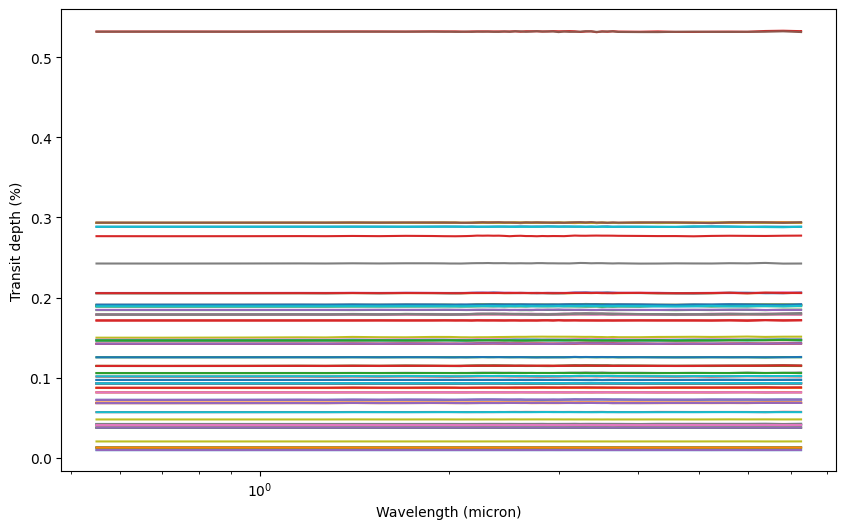

In [8]:
fig = plt.figure(figsize=(10,6))
for i in range(0, 100):
    visualise_spectrum(spectra_train[i])
plt.show()


### Répartition des labels

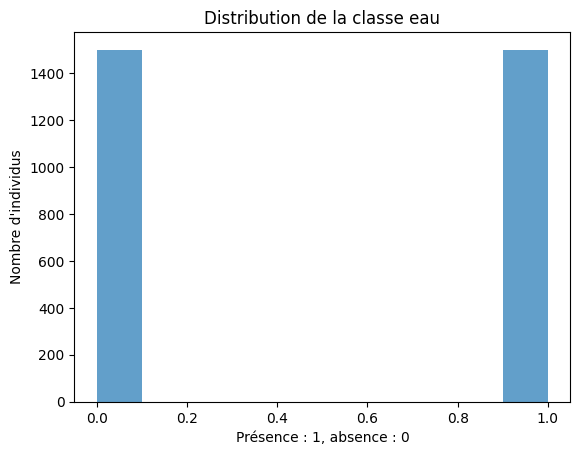

In [9]:
plt.hist(targets_train['eau'], alpha=0.7)
plt.title(f'Distribution de la classe eau')
plt.xlabel('Présence : 1, absence : 0')
plt.ylabel('Nombre d\'individus')
plt.show()

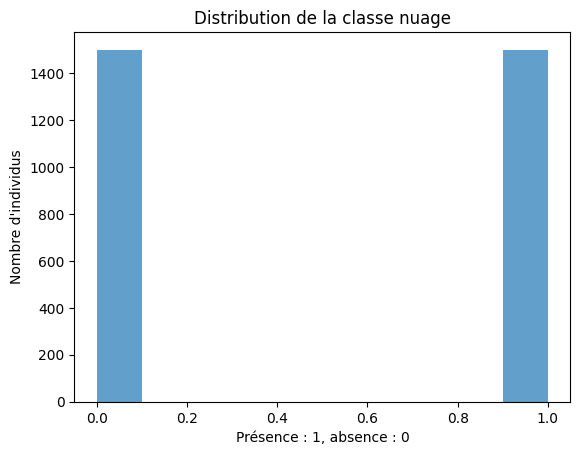

In [10]:
plt.hist(targets_train['nuage'], alpha=0.7)
plt.title(f'Distribution de la classe nuage')
plt.xlabel('Présence : 1, absence : 0')
plt.ylabel('Nombre d\'individus')
plt.show()

Il y a autant de spectres avec eau et sans eau, tout comme pour le nuage.
## Transformation des données
Nous transformons les données auxiliaires en rapport de la masse et du rayon de jupiter pour les données de la planète, et de la masse et rayon solaires pour les données de l'étoile.

In [11]:
RJUP = 69911000
MJUP = 1.898e27
RSOL = 696340000
MSOL = 1.9891e30

On peut déduire le rayon théorique de la planète depuis la masse et la gravité de surface de la planète depuis la formule : $$R_p = \sqrt{\frac{G_p * M_p}{g}}$$ où g est la constance universelle de gravitation.

In [12]:
auxiliary_train["planet_surface_gravity"] = 20
# calcul du rayon théorique
auxiliary_train["th_radius"] = np.sqrt(auxiliary_train["planet_mass_kg"]*6.67e-11/auxiliary_train["planet_surface_gravity"])/RJUP
auxiliary_train['star_radius'] = auxiliary_train['star_radius_m']/RSOL # Changement de mètre en proprotion du rayon solaire

auxiliary_train['planet_mass'] = auxiliary_train['planet_mass_kg']/MJUP # Changement de kilos vers proportion de masse de jupiter
auxiliary_train['star_mass'] = auxiliary_train['star_mass_kg']/MSOL # Changement de kilos vers proportion de masse solaire


useful_aux_columns = ["star_radius", "star_temperature", "planet_mass", "semi_major_axis_m", "star_mass", "th_radius"]


auxiliary_train = auxiliary_train[useful_aux_columns]
auxiliary_train


,star_radius,star_temperature,planet_mass,semi_major_axis_m,star_mass,th_radius
0,0.710002,5033.0,0.066516,2.277510e+10,0.789722,0.293505
1,0.850002,5320.0,0.020861,1.217744e+10,0.859697,0.164369
2,0.550002,3985.0,0.047197,1.057672e+10,0.579796,0.247234
3,0.210001,2988.0,0.020074,1.431672e+10,0.189933,0.161240
4,0.640002,4925.0,0.044051,1.795200e+10,0.689757,0.238851
...,...,...,...,...,...,...
2995,0.850002,5320.0,0.020861,1.217744e+10,0.859697,0.164369
2996,0.650002,4316.0,0.012145,1.171368e+10,0.649771,0.125417
2997,1.120003,6169.0,0.083602,4.425168e+10,1.099613,0.329047
2998,0.550002,3985.0,0.047197,1.057672e+10,0.579796,0.247234


Dans ce notebook de baseline, nous n'utilisons pas les données de bruits :

In [13]:
spectra_data = spectra_train[:,:,1]

## Split train/test

In [14]:
proportion_train = int(len(spectra_data)*0.8)
indices_shuffle = np.random.permutation(len(spectra_data))

train_spectra = spectra_data[indices_shuffle[:proportion_train]]
val_spectra = spectra_data[indices_shuffle[proportion_train:]]

train_aux = auxiliary_train.iloc[indices_shuffle[:proportion_train]].values
val_aux = auxiliary_train.iloc[indices_shuffle[proportion_train:]].values


Y_train = targets_train.iloc[indices_shuffle[:proportion_train]].values[:,1:]
Y_val = targets_train.iloc[indices_shuffle[proportion_train:]].values[:,1:]

In [15]:
print(f'shape de train_spectra : {train_spectra.shape}, shape de train_aux : {train_aux.shape}')
print(f'shape de val_spectra : {val_spectra.shape}, shape de val_aux : {val_aux.shape}')
print(f'shape de Y_train : {Y_train.shape}')
print(f'shape de Y_val : {Y_val.shape}')

shape de train_spectra : (2400, 52), shape de train_aux : (2400, 6)
shape de val_spectra : (600, 52), shape de val_aux : (600, 6)
shape de Y_train : (2400, 2)
shape de Y_val : (600, 2)


## Normalisation
On peut normaliser ensemble les 52 premières colonnes, le spectre, et ensuite chaque colonne à part pour les données auxiliaire. Dans cette baseline on utilise une division par la valeur maximale, à vous de trouver une meilleure normalisation.

In [16]:
def max_normalization(spectra):
    normalized_spectra = []
    for spectrum in spectra:
        max_val = np.max(spectrum)
        normalized_spectrum = spectrum / max_val
        normalized_spectra.append(normalized_spectrum)
    return np.array(normalized_spectra)

In [17]:
train_spectra = max_normalization(train_spectra)
val_spectra = max_normalization(val_spectra)


list_max_val_aux = []

for i in range(0, train_aux.shape[1]):
    max_val = np.max(train_aux[:, i])
    list_max_val_aux.append(max_val)
    train_aux[:, i] = train_aux[:, i] / max_val
    val_aux[:, i] = val_aux[:, i] / max_val

In [18]:
print(f"Histogramme train : {np.histogram(train_spectra)}")
print(f"Histogramme val : {np.histogram(val_spectra)}")


Histogramme train : (array([    2,    41,   116,   439,  1401,  4989, 13426, 31213, 48889,
       24284]), array([0.9860894 , 0.98748046, 0.98887152, 0.99026258, 0.99165364,
       0.9930447 , 0.99443576, 0.99582682, 0.99721788, 0.99860894,
       1.        ]))
Histogramme val : (array([   10,    20,    75,   214,   493,  1527,  3773,  8054, 11734,
        5300]), array([0.9870385 , 0.98833465, 0.9896308 , 0.99092695, 0.9922231 ,
       0.99351925, 0.9948154 , 0.99611155, 0.9974077 , 0.99870385,
       1.        ]))


In [19]:
X_train = np.append(train_spectra, train_aux, axis=1)
X_val = np.append(val_spectra, val_aux, axis=1)


## ML
### RF

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.utils import shuffle


max_depth = 6
clf_h2o = RandomForestClassifier(n_estimators=20, max_depth=max_depth, random_state=0)
clf_clouds = RandomForestClassifier(n_estimators=20, max_depth=max_depth, random_state=0)

clf_h2o.fit(X_train, Y_train[:,0])
clf_clouds.fit(X_train, Y_train[:,1])

res_val_h2o = clf_h2o.predict(X_val)
res_val_clouds = clf_clouds.predict(X_val)





In [21]:
from sklearn.metrics import accuracy_score
print('acc h2o rf :' + str(accuracy_score(Y_val[:,0], res_val_h2o)))
print('acc clouds rf :' + str(accuracy_score(Y_val[:,1], res_val_clouds)))

acc h2o rf :0.9266666666666666
acc clouds rf :0.75


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def print_confusion_matrix(confusion_matrix, axes, class_label, class_names, fontsize=14):

    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names,
    )

    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d", cbar=False, ax=axes)
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    axes.set_ylabel('Vérité')
    axes.set_xlabel('Prédictions')
    axes.set_title("Matrice de confusion pour la classe - " + class_label)

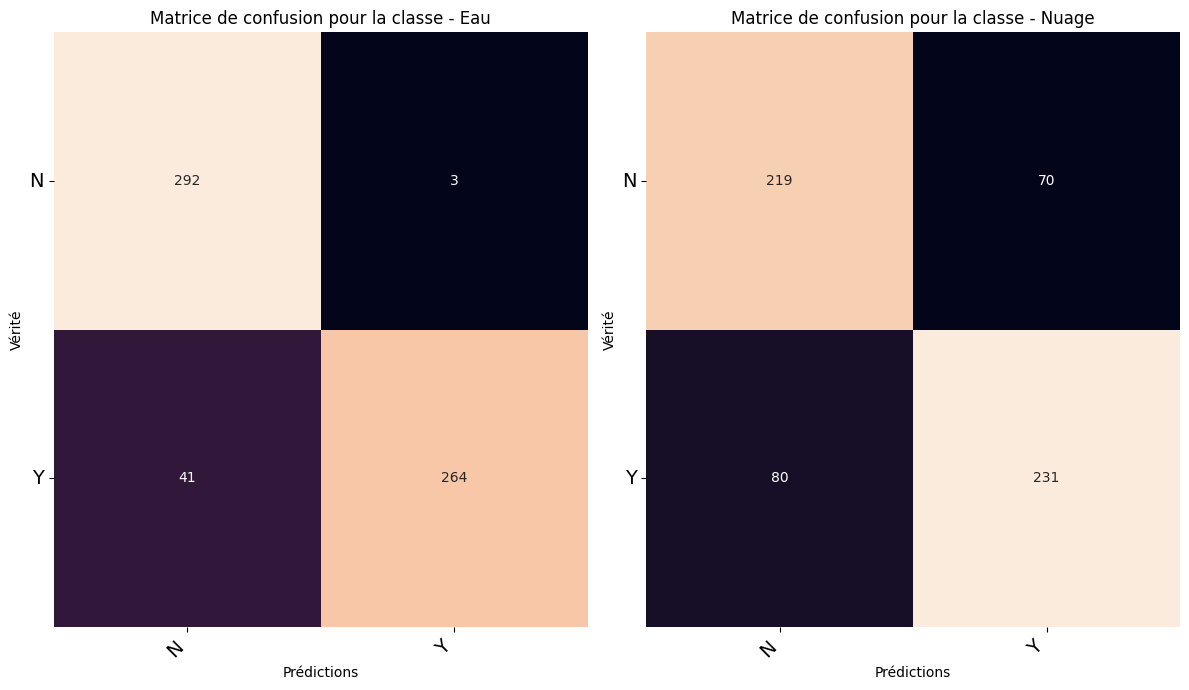

In [23]:
vis_arr_0 = confusion_matrix(Y_val[:, 0], res_val_h2o)
vis_arr_1 = confusion_matrix(Y_val[:, 1], res_val_clouds)

fig, ax = plt.subplots(1, 2, figsize=(12, 7))
labels = ["Eau","Nuage"]
for axes, cfs_matrix, label in zip(ax.flatten(), [vis_arr_0, vis_arr_1], labels):
    print_confusion_matrix(cfs_matrix, axes, label, ["N", "Y"])

fig.tight_layout()
plt.show()

## Prédiction

In [24]:
spectra_test = np.load(f'{root_dataset}/spectra_test.npy')
test_spectra = spectra_test[:,:,1]

auxiliary_test = pd.read_csv(f'{root_dataset}/auxiliary_test.csv')

auxiliary_test["planet_surface_gravity"] = 20
# calcul du rayon théorique
auxiliary_test["th_radius"] = np.sqrt(auxiliary_test["planet_mass_kg"]*6.67e-11/auxiliary_test["planet_surface_gravity"])/RJUP
auxiliary_test['star_radius'] = auxiliary_test['star_radius_m']/RSOL # Changement de mètre en proprotion du rayon solaire

auxiliary_test['planet_mass'] = auxiliary_test['planet_mass_kg']/MJUP # Changement de kilos vers proportion de masse de jupiter
auxiliary_test['star_mass'] = auxiliary_test['star_mass_kg']/MSOL # Changement de kilos vers proportion de masse solaire


useful_aux_columns = ["star_radius", "star_temperature", "planet_mass", "semi_major_axis_m", "star_mass", "planet_surface_gravity", "th_radius"]


test_aux = auxiliary_test[useful_aux_columns].values[:,1:]
auxiliary_test[useful_aux_columns]

,star_radius,star_temperature,planet_mass,semi_major_axis_m,star_mass,planet_surface_gravity,th_radius
0,0.510001,3476.0,0.019760,4.293520e+09,0.509821,20,0.159971
1,0.650002,4316.0,0.012145,1.171368e+10,0.649771,20,0.125417
2,0.640002,4925.0,0.044051,1.795200e+10,0.689757,20,0.238851
3,0.380001,3506.0,0.015040,1.078616e+10,0.389863,20,0.139565
4,0.210001,2988.0,0.020074,1.431672e+10,0.189933,20,0.161240
...,...,...,...,...,...,...,...
1027,0.650002,4316.0,0.012145,1.171368e+10,0.649771,20,0.125417
1028,0.600002,4305.0,0.004090,5.871800e+09,0.609785,20,0.072784
1029,0.380001,3506.0,0.015040,1.078616e+10,0.389863,20,0.139565
1030,0.650002,4316.0,0.012145,1.171368e+10,0.649771,20,0.125417


In [25]:

test_spectra = max_normalization(test_spectra)


for i in range(0, test_aux.shape[1]):
    test_aux[:, i] = test_aux[:, i] / list_max_val_aux[i]


print(f"Histogramme test : {np.histogram(test_spectra)}")


Histogramme test : (array([    4,    15,    79,   186,   875,  2601,  6878, 16004, 19203,
        7819]), array([0.98872172, 0.98984955, 0.99097738, 0.9921052 , 0.99323303,
       0.99436086, 0.99548869, 0.99661652, 0.99774434, 0.99887217,
       1.        ]))


In [26]:
X_test = np.append(test_spectra, test_aux, axis=1)


In [27]:
res_test_h2o = clf_h2o.predict(X_test)
res_test_clouds = clf_clouds.predict(X_test)

In [28]:
submission_df = pd.DataFrame({
    'id': range(len(res_test_h2o)),
    'eau': res_test_h2o,
    'nuage': res_test_clouds
})

submission_df.set_index('id', inplace=True)

submission_df.to_csv("submission.csv")

